In [1]:
import pandas as pd 
import seaborn as sns 
import matplotlib.pyplot as plt
import numpy as np

In [2]:
res = pd.read_csv("results.csv")
res

,Unnamed: 0,trial_id,iteration,test_metric,strategy,seed,score
0,0,1807d_00000,0,0.912167,least_confidence,1,273.809512
1,1,1807d_00000,1,0.922842,least_confidence,1,273.809512
2,2,1807d_00000,2,0.874752,least_confidence,1,273.809512
3,3,1807d_00000,3,0.898536,least_confidence,1,273.809512
4,4,1807d_00000,4,0.886821,least_confidence,1,273.809512
...,...,...,...,...,...,...,...
7270,7270,1807d_00024,286,0.950332,random,5,272.554363
7271,7271,1807d_00024,287,0.937594,random,5,272.554363
7272,7272,1807d_00024,288,0.937594,random,5,272.554363
7273,7273,1807d_00024,289,0.939985,random,5,272.554363


In [3]:
res[res.strategy=="random"]

,Unnamed: 0,trial_id,iteration,test_metric,strategy,seed,score
5820,5820,1807d_00020,0,0.902657,random,1,267.925193
5821,5821,1807d_00020,1,0.900168,random,1,267.925193
5822,5822,1807d_00020,2,0.908120,random,1,267.925193
5823,5823,1807d_00020,3,0.894231,random,1,267.925193
5824,5824,1807d_00020,4,0.914370,random,1,267.925193
...,...,...,...,...,...,...,...
7270,7270,1807d_00024,286,0.950332,random,5,272.554363
7271,7271,1807d_00024,287,0.937594,random,5,272.554363
7272,7272,1807d_00024,288,0.937594,random,5,272.554363
7273,7273,1807d_00024,289,0.939985,random,5,272.554363


In [4]:
aucs = res.drop_duplicates(subset=["strategy","seed"])
agg = aucs.groupby("strategy")["score"]
mean_aucs, std_aucs = agg.mean(), agg.std()
aucs = pd.concat((mean_aucs, std_aucs), axis=1)
aucs.columns = ["avg", "stdv"]
aucs["score"] = aucs.apply(lambda row: f"{row.avg:.2f} ± {row.stdv:.2f}"  ,axis=1)
label_to_auc = dict(zip(aucs.index, aucs["score"]))

/tmp/ipykernel_11104/2952143151.py:8: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  plt.gca().set_xticklabels([int(label) + 10 for label in current_xticks])


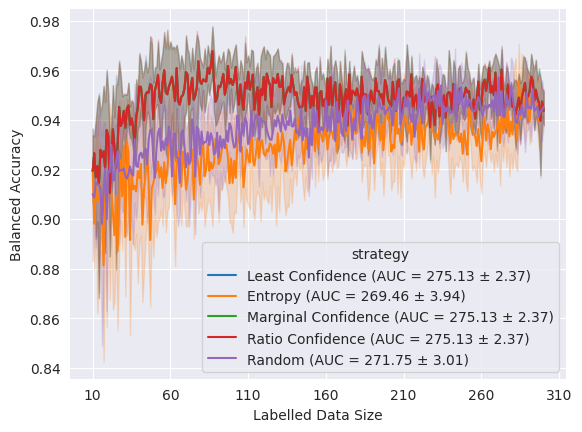

In [6]:
sns.set_style("darkgrid")

sns.lineplot(data=res, x="iteration", y="test_metric", hue="strategy")
plt.ylabel("Balanced Accuracy")
plt.xlabel("Labelled Data Size")

current_xticks = plt.gca().get_xticks()
plt.gca().set_xticklabels([int(label) + 10 for label in current_xticks])

ax = plt.gca()
legend = ax.get_legend()
for text in legend.get_texts():
    label = text.get_text()
    new_label = f"{label.replace('_', ' ').title()} (AUC = {label_to_auc[label]})"
    text.set_text(new_label)
    

for spine in ax.spines.values():
    spine.set_visible(False)